# Tutorial 2: Classify Cubic vs Non-Cubic INS Spectra

**Organizer**: Dr. José I. Robledo

Professor Balseiro Institute, Bariloche Atomic centre, Argentina (CAB-CNEA)

Researcher at the National Scientific Council of Argentina (CONICET)

---

## Goal of this tutorial

In this notebook we will study a simple binary **classification** problem using inelastic neutron scattering spectra, to comprehend how classification problems in Machine Learning are stated using `PyTorch`.

The goal is to decide whether a crystal is:
- `cubic`, or
- `non_cubic`

using only the powder INS spectrum $S(Q,E)$ stored in `powder_2Dmesh_coh_0K.csv`.

As in Tutorial 1, we will use the database that is provided in the Open Dataset published in [Scientific Data: "A database of synthetic inelastic neutron scattering spectra from molecules and crystals" (Scientific Data volume 10, Article number: 54 (2023) )](https://www.nature.com/articles/s41597-022-01926-x).

The `crystals` folder contains one subfolder per material, and each subfolder includes the simulated neutron-scattering files associated with that crystal. The summary file `crystals.dat` provides the crystal ID and the crystallographic information that we will use to construct the labels.

### Specific objectives:

- how to build binary labels from crystallographic metadata
- how to load a 2D INS spectrum from CSV
- how to convert each spectrum into a fixed-size image for machine learning
- how to split crystals into train and test sets
- how to train a small convolutional neural network with PyTorch
- how to interpret an accuracy curve and a confusion matrix

---


## General Imports


## Preparing a dataset for Machine Learning

### Shared helper functions

The common functions used in these tutorials now live in the file `tnt2026_utils.py`.
That file contains the dataset-parsing, spectrum-loading, resizing, normalization, and splitting utilities that are reused across the three notebooks.

This notebook then focuses only on the parts that are specific to the classification task.


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from tnt2026_utils import (
    build_crystal_index,
    compute_image_stats,
    dataframe_train_test_split,
    infer_project_root,
    load_spectrum_grid,
    make_image_tensor,
    seed_everything,
)

seed_everything(42)
PROJECT_ROOT = infer_project_root()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

### Extraction and loading of input and output features

Here, each crystal contributes:
- one input: the powder INS intensity map $S(Q,E)$
- one output label: `cubic` or `non_cubic`

This means that our classifier will try to learn a function of the form:

$$
\hat{y} = f_w(x)
$$

where:
- $x$ is the INS spectrum represented as an image,
- $w$ are the trainable parameters of the neural network,
- $\hat{y}$ is the predicted class.

Because the original dataset is imbalanced, we balance the number of crystals in the two classes before training.


In [32]:
MAX_SAMPLES = 10000
IMAGE_SIZE = (64, 64)
TEST_SIZE = 0.3
BATCH_SIZE = 128
EPOCHS = 25
LR = 0.8e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 6
CUBIC_SYMMETRY = ["cubic"]
BALANCE_CLASSES = True

index = build_crystal_index(
    PROJECT_ROOT / "crystals",
    PROJECT_ROOT / "crystals.dat",
    max_samples=MAX_SAMPLES,
    seed=42,
)

index["symmetry_group"] = "non_cubic"
index.loc[index["crystal_system"].isin(CUBIC_SYMMETRY), "symmetry_group"] = "cubic"

if BALANCE_CLASSES:
    class_counts = index["symmetry_group"].value_counts()
    target_count = int(class_counts.min())
    index = (
        index.groupby("symmetry_group", group_keys=False)
        .apply(lambda group: group.sample(n=target_count, random_state=42))
        .sample(frac=1.0, random_state=42)
        .reset_index(drop=True)
    )

label_names = sorted(index["symmetry_group"].unique())
label_to_id = {label: idx for idx, label in enumerate(label_names)}
index["label_id"] = index["symmetry_group"].map(label_to_id)

train_df, test_df = dataframe_train_test_split(
    index,
    test_size=TEST_SIZE,
    seed=42,
    stratify_col="symmetry_group",
)

print("Classes used:", label_names)
print("Balanced dataset enabled:", BALANCE_CLASSES)
print("Crystals after balancing:", len(index))
print("Full dataset class counts:")
print(index["symmetry_group"].value_counts())
print("Train class counts:")
print(train_df["symmetry_group"].value_counts())
print("Test class counts:")
print(test_df["symmetry_group"].value_counts())


Classes used: ['cubic', 'non_cubic']
Balanced dataset enabled: True
Crystals after balancing: 2166
Full dataset class counts:
symmetry_group
non_cubic    1083
cubic        1083
Name: count, dtype: int64
Train class counts:
symmetry_group
non_cubic    758
cubic        758
Name: count, dtype: int64
Test class counts:
symmetry_group
non_cubic    325
cubic        325
Name: count, dtype: int64


/var/folders/bc/_wptcs4j7cdc5ydgz16yb2jm0000gn/T/ipykernel_62517/2099115368.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=target_count, random_state=42))


## Preprocessing the INS spectra

Neural networks need all inputs to have the same size, so each `S(Q,E)` spectrum is resized to a fixed image shape. We will control this with the variable `IMAGE_SIZE`.

We also apply two standard transformations:

$$x_{log} = \log(1 + x)$$

This compresses very large intensities and makes the scale easier to learn.

$$x_{norm} = (x - \mu) / \sigma$$

Here $\mu$ and $\sigma$ are computed from the **training set only**.
This is the usual z-score normalization and helps optimization behave more stably.

Finally, we balance the dataset before splitting it, so that the number of cubic and non-cubic crystals is the same.


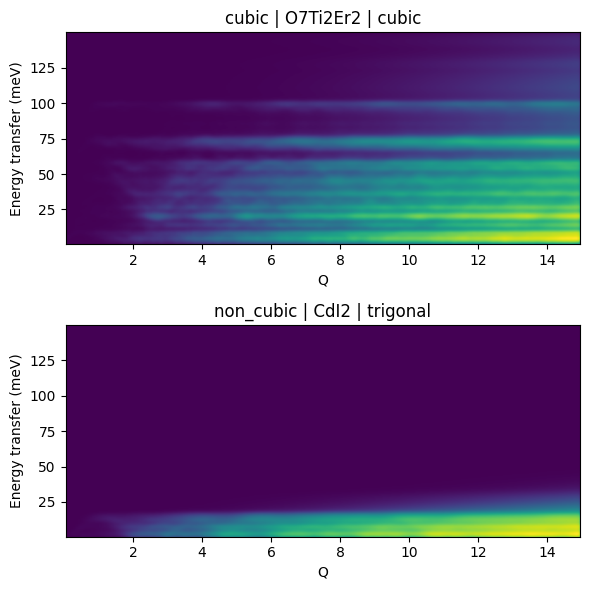

In [33]:
fig, axes = plt.subplots(len(label_names), 1, figsize=(6, 3 * len(label_names)), squeeze=False)

for row_idx, label in enumerate(label_names):
    sample = train_df.loc[train_df["symmetry_group"] == label].sample(1, random_state=42).iloc[0]
    q_values, e_values, image = load_spectrum_grid(sample["csv_path"])

    ax = axes[row_idx, 0]
    ax.imshow(
        np.log1p(image).T,
        origin="lower",
        aspect="auto",
        extent=[q_values.min(), q_values.max(), e_values.min(), e_values.max()],
        cmap="viridis",
    )
    ax.set_title(f"{label} | {sample['formula']} | {sample['crystal_system']}")
    ax.set_xlabel("Q")
    ax.set_ylabel("Energy transfer (meV)")

plt.tight_layout()
plt.show()


In [34]:
mean_img, std_img = compute_image_stats(train_df["csv_path"], size=IMAGE_SIZE, base_transform="log1p")

X_train = make_image_tensor(train_df, size=IMAGE_SIZE, base_transform="log1p", mean=mean_img, std=std_img)
X_test = make_image_tensor(test_df, size=IMAGE_SIZE, base_transform="log1p", mean=mean_img, std=std_img)

y_train = torch.tensor(train_df["label_id"].to_numpy(), dtype=torch.long)
y_test = torch.tensor(test_df["label_id"].to_numpy(), dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

majority_baseline = max((y_test == 0).float().mean().item(), (y_test == 1).float().mean().item())

print("Spectrum tensor shape:", tuple(X_train.shape))
print(f"Majority-class baseline on test set: {majority_baseline:.3f}")


Spectrum tensor shape: (1516, 1, 64, 64)
Majority-class baseline on test set: 0.500


## Classification Model and Loss

We use a small convolutional neural network (CNN), because the input is a 2D image-like object.

The CNN scans the `S(Q,E)` map with learnable filters, progressively combines local patterns, and finally predicts one of the two classes.

The final layer outputs two numbers called **logits**. These are converted into class probabilities through the softmax function:

$$
p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}
$$

where $z_k$ is the logit associated with class $k$.

During training we minimize the [cross-entropy loss](https://docs.pytorch.org/docs/2.12/generated/torch.nn.CrossEntropyLoss.html), which encourages the model to assign high probability to the correct class.

For evaluation, we will report the raw accuracy. A random or naive classifier would give about `50%`, and a better model should go clearly above that value.


In [ ]:
class CNNClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)


model = CNNClassifier(n_classes=len(label_names)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss()


def evaluate(loader):
    model.train(False)
    logits_all = []
    y_all = []
    total_loss = 0.0
    total_items = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        with torch.no_grad():
            logits = model(xb)
            loss = loss_fn(logits, yb)
        logits_all.append(logits.cpu())
        y_all.append(yb.cpu())
        total_loss += loss.item() * len(xb)
        total_items += len(xb)

    logits_all = torch.cat(logits_all)
    y_all = torch.cat(y_all)
    pred = logits_all.argmax(dim=1)
    acc = (pred == y_all).float().mean().item()
    return total_loss / total_items, acc, pred.numpy(), y_all.numpy()


def train_one_epoch(loader):
    model.train(True)
    total_loss = 0.0
    total_items = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)
        total_items += len(xb)

    return total_loss / total_items


history = []
best_state = None
best_test_acc = -1.0
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(train_loader)
    train_eval_loss, train_acc, _, _ = evaluate(train_loader)
    test_loss, test_acc, _, _ = evaluate(test_loader)
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_eval_loss,
            "test_loss": test_loss,
            "train_acc": train_acc,
            "test_acc": test_acc,
        }
    )
    print(
        f"epoch {epoch:02d} | train_acc={train_acc:.3f} | test_acc={test_acc:.3f}"
    )

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch:02d}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df


epoch 01 | train_acc=0.500 | test_acc=0.500
epoch 02 | train_acc=0.500 | test_acc=0.500
epoch 03 | train_acc=0.511 | test_acc=0.511
epoch 04 | train_acc=0.570 | test_acc=0.554
epoch 05 | train_acc=0.748 | test_acc=0.738
epoch 06 | train_acc=0.760 | test_acc=0.752
epoch 07 | train_acc=0.739 | test_acc=0.735
epoch 08 | train_acc=0.771 | test_acc=0.774
epoch 09 | train_acc=0.766 | test_acc=0.754
epoch 10 | train_acc=0.767 | test_acc=0.723
epoch 11 | train_acc=0.772 | test_acc=0.774
epoch 12 | train_acc=0.756 | test_acc=0.729
epoch 13 | train_acc=0.785 | test_acc=0.783
epoch 14 | train_acc=0.783 | test_acc=0.775
epoch 15 | train_acc=0.706 | test_acc=0.691
epoch 16 | train_acc=0.791 | test_acc=0.777
epoch 17 | train_acc=0.780 | test_acc=0.762
epoch 18 | train_acc=0.764 | test_acc=0.737
epoch 19 | train_acc=0.798 | test_acc=0.762
Early stopping at epoch 19


,epoch,train_loss,test_loss,train_acc,test_acc
0,1,0.694988,0.694791,0.500000,0.500000
1,2,0.703029,0.702484,0.500000,0.500000
2,3,0.695269,0.696474,0.510554,0.510769
3,4,0.657861,0.668181,0.569921,0.553846
4,5,0.533947,0.545564,0.748021,0.738462
5,6,0.485522,0.500817,0.759894,0.752308
6,7,0.513098,0.519008,0.739446,0.735385
7,8,0.464935,0.476895,0.771108,0.773846
8,9,0.465997,0.489528,0.766491,0.753846
9,10,0.508552,0.548997,0.767150,0.723077


## How To Read the Final Plot

The first panel shows how the train and test accuracy evolve during optimization.
If the test score improves and then stabilizes, the model is learning a useful decision rule.

The confusion matrix shows, for each true class, how often the model predicts each possible class.

For a good classifier:
- the diagonal entries should be large,
- the off-diagonal entries should be small.

Since this is a balanced binary problem, a baseline model would score about `50%` accuracy.
So a result clearly above `0.50` indicates that the INS spectra contain information that helps distinguish cubic from non-cubic crystals.


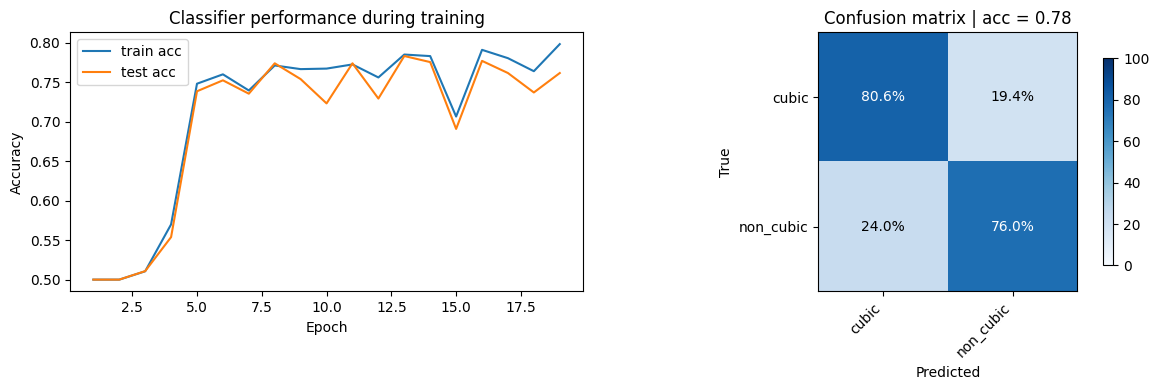

pred,cubic,non_cubic
true,,
cubic,80.615385,19.384615
non_cubic,24.000000,76.000000


In [36]:
test_loss, test_acc, test_pred, test_true = evaluate(test_loader)

cm = pd.crosstab(
    pd.Series([label_names[i] for i in test_true], name="true"),
    pd.Series([label_names[i] for i in test_pred], name="pred"),
    normalize="index",
    dropna=False,
) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_acc"], label="train acc")
axes[0].plot(history_df["epoch"], history_df["test_acc"], label="test acc")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Classifier performance during training")
axes[0].legend()

im = axes[1].imshow(cm.to_numpy(), cmap="Blues", vmin=0, vmax=100)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(
            j,
            i,
            f"{cm.iloc[i, j]:.1f}%",
            ha="center",
            va="center",
            color="white" if cm.iloc[i, j] > 50 else "black",
        )

axes[1].set_xticks(np.arange(len(cm.columns)))
axes[1].set_xticklabels(cm.columns, rotation=45, ha="right")
axes[1].set_yticks(np.arange(len(cm.index)))
axes[1].set_yticklabels(cm.index)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title(f"Confusion matrix | acc = {test_acc:.2f}")
fig.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

cm


## Conclusion

In this notebook we built a simple classification pipeline for neutron-scattering data. We converted each powder INS spectrum into a normalized image, constructed binary labels from crystallographic metadata, trained a small CNN, and evaluated the result using accuracy curves and a confusion matrix.

In this tutorial, we have seen that:
- raw neutron-scattering spectra can be converted into image-like ML inputs,
- a convolutional neural network can learn (within some error) structural labels from $S(Q,E)$ maps,
- the full workflow includes data loading, preprocessing, train/test splitting, modeling, training, and evaluation.

This is a compact, practical example of how machine learning can be applied to a classification problem in neutron science. A natural next step is to try more classes, compare different input representations, or explore latent representations with unsupervised learning.
